In [8]:
from pathlib import Path
import pandas as pd
import joblib
import numpy as np

from lazypredict.Supervised import REGRESSORS
from lazypredict import LazyRegressor

In [ ]:

artefacts_dir = Path("../artefacts")
split_dir = Path("../data/processed/eu/splits")


# load raw split data (not encoded, not scaled, only split)
X_train_raw = pd.read_parquet(split_dir / "X_train_raw.parquet")
X_test_raw = pd.read_parquet(split_dir / "X_test_raw.parquet")


# load encoded split data
X_train_encoded = pd.read_parquet(split_dir / "X_train_encoded.parquet")
X_test_encoded = pd.read_parquet(split_dir / "X_test_encoded.parquet")


# load encoded and scaled split data (FOR LINEAR MODELS)
X_train_encoded_scaled = pd.read_parquet(split_dir / "X_train_encoded_scaled.parquet")
X_test_encoded_scaled = pd.read_parquet(split_dir / "X_test_encoded_scaled.parquet")

y_train = pd.read_parquet(split_dir / "y_train.parquet")["Ewltp (g/km)"]
y_test = pd.read_parquet(split_dir / "y_test.parquet")["Ewltp (g/km)"]

# load the encoder and the scaler
ohe_encoder = joblib.load(artefacts_dir / "ohe_encoder.joblib")
scaler = joblib.load(artefacts_dir / "numeric_scaler.joblib")

# Control
numeric_cols = [
    "ec (cm3)", "ep (KW)", "m (kg)", "z (Wh/km)", 
    "Electric range (km)"
]

print("X_train_encoded_scaled shape:", X_train_encoded_scaled.shape)
print("X_train_encoded_scaled columns list:", X_train_encoded_scaled.columns.tolist())
print("X_train_encoded_scaled empty data:", X_train_encoded_scaled.isna().sum().sum())
print("X_train_encoded_scaled data types:", X_train_encoded_scaled.dtypes.value_counts())
#Print verification of scaled data (mean ≈ 0, std ≈ 1)
print("X_train_encoded_scaled scaled columns mean:\n", X_train_encoded_scaled[numeric_cols].mean().round(4))
print("\nX_train_encoded_scaled scaled columns std:\n", X_train_encoded_scaled[numeric_cols].std().round(4))
print("\n*********\n")
print("X_test_encoded_scaled shape:", X_test_encoded_scaled.shape)
print("X_test_encoded_scaled columns list:", X_test_encoded_scaled.columns.tolist())
print("X_test_encoded_scaled empty data:", X_test_encoded_scaled.isna().sum().sum())
print("X_test_encoded_scaled data types:", X_test_encoded_scaled.dtypes.value_counts())


X_train_encoded_scaled shape: (91896, 19)
X_train_encoded_scaled columns list: ['ec (cm3)', 'ep (KW)', 'm (kg)', 'z (Wh/km)', 'Electric range (km)', 'Ft_diesel', 'Ft_petrol', 'Ft_petrol/electric', 'Fm_H', 'Fm_M', 'Fm_P', 'IT_28', 'IT_29', 'IT_32', 'IT_33', 'IT_37', 'IT_none', 'Make_Encoded', 'Model_Frequency']
X_train_encoded_scaled empty data: 0
X_train_encoded_scaled data types: float64    19
Name: count, dtype: int64
X_train_encoded_scaled scaled columns mean:
 ec (cm3)               0.0
ep (KW)               -0.0
m (kg)                -0.0
z (Wh/km)              0.0
Electric range (km)    0.0
dtype: float64

X_train_encoded_scaled scaled columns std:
 ec (cm3)               1.0
ep (KW)                1.0
m (kg)                 1.0
z (Wh/km)              1.0
Electric range (km)    1.0
dtype: float64

*********

X_test_encoded_scaled shape: (22975, 19)
X_test_encoded_scaled columns list: ['ec (cm3)', 'ep (KW)', 'm (kg)', 'z (Wh/km)', 'Electric range (km)', 'Ft_diesel', 'Ft_petrol', '

## We want to start with Lazypredict, let's see the list of Regressors available in Lazypredict:

In [4]:
regressors = [
    cls
    for name, cls in REGRESSORS
]

print(len(regressors))
print([cls.__name__ for cls in regressors])

40
['AdaBoostRegressor', 'BaggingRegressor', 'BayesianRidge', 'DecisionTreeRegressor', 'DummyRegressor', 'ElasticNet', 'ElasticNetCV', 'ExtraTreeRegressor', 'ExtraTreesRegressor', 'GammaRegressor', 'GaussianProcessRegressor', 'GradientBoostingRegressor', 'HistGradientBoostingRegressor', 'HuberRegressor', 'KNeighborsRegressor', 'KernelRidge', 'Lars', 'LarsCV', 'Lasso', 'LassoCV', 'LassoLars', 'LassoLarsCV', 'LassoLarsIC', 'LinearRegression', 'LinearSVR', 'MLPRegressor', 'NuSVR', 'OrthogonalMatchingPursuit', 'OrthogonalMatchingPursuitCV', 'PassiveAggressiveRegressor', 'PoissonRegressor', 'QuantileRegressor', 'RANSACRegressor', 'RandomForestRegressor', 'Ridge', 'RidgeCV', 'SGDRegressor', 'SVR', 'TransformedTargetRegressor', 'TweedieRegressor']


## Let's calculate our Kernel Matrix:

In [ ]:
n = len(X_train_encoded_scaled)

print(f"Training samples: {n:,}")
print(f"Kernel matrix entries: {n:,} x {n:,}")
print(f"Kernel matrix memory (float64): {n*n*8 / 1024**4:.2f} TB")

Training samples: 91,896
Kernel matrix entries: 91,896 × 91,896
Kernel matrix memory (float64): 0.06 TiB


## - **1 TB = 1024 GB**
## - **0.06 TB ~=0.06x1024 ~=61.44GB**
### That means if we use Kernel PCA, Kernel SVM, Gaussian Processes etc., we'll need approximately 61.44GB+ RAM
### My computer has only 32GB of ram :)
###  Let's remove GaussianProcessRegressor from the list of models to be executed in Lazypredict and create a safe_regressors list:

In [7]:
safe_regressors = [
    cls
    for name, cls in REGRESSORS
    if name != "GaussianProcessRegressor"
]

print(len(safe_regressors))
print([cls.__name__ for cls in safe_regressors])

39
['AdaBoostRegressor', 'BaggingRegressor', 'BayesianRidge', 'DecisionTreeRegressor', 'DummyRegressor', 'ElasticNet', 'ElasticNetCV', 'ExtraTreeRegressor', 'ExtraTreesRegressor', 'GammaRegressor', 'GradientBoostingRegressor', 'HistGradientBoostingRegressor', 'HuberRegressor', 'KNeighborsRegressor', 'KernelRidge', 'Lars', 'LarsCV', 'Lasso', 'LassoCV', 'LassoLars', 'LassoLarsCV', 'LassoLarsIC', 'LinearRegression', 'LinearSVR', 'MLPRegressor', 'NuSVR', 'OrthogonalMatchingPursuit', 'OrthogonalMatchingPursuitCV', 'PassiveAggressiveRegressor', 'PoissonRegressor', 'QuantileRegressor', 'RANSACRegressor', 'RandomForestRegressor', 'Ridge', 'RidgeCV', 'SGDRegressor', 'SVR', 'TransformedTargetRegressor', 'TweedieRegressor']


## Let's run Lazypredict with these 39 safe to run Regressors now:

In [ ]:
reg = LazyRegressor(
    verbose=1,
    ignore_warnings=True,
    regressors=safe_regressors,
)

models, predictions = reg.fit(
    X_train_encoded_scaled,
    X_test_encoded_scaled,
    y_train,
    y_test,
)

models

  0%|          | 0/40 [00:00<?, ?it/s]

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.998215,0.998217,2.308104,6.264550
RandomForestRegressor,0.998131,0.998133,2.361942,8.287210
BaggingRegressor,0.998108,0.998110,2.376427,0.845118
DecisionTreeRegressor,0.997987,0.997989,2.451415,0.136697
ExtraTreeRegressor,0.997828,0.997830,2.546453,0.084508
XGBRegressor,0.997728,0.997730,2.604101,0.345378
KNeighborsRegressor,0.997461,0.997463,2.753313,0.693076
HistGradientBoostingRegressor,0.996308,0.996311,3.319933,1.076997
MLPRegressor,0.993641,0.993646,4.357093,18.390629


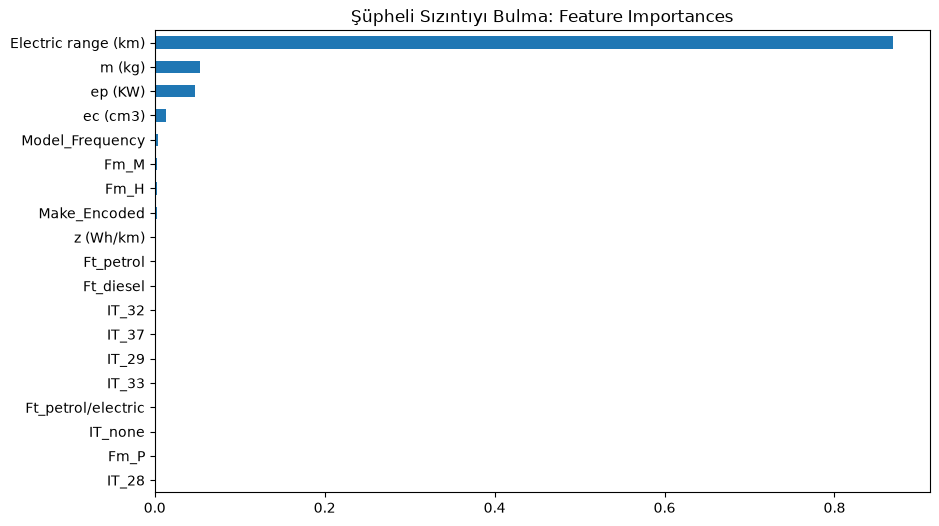

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Hızlı bir Random Forest eğitelim
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train_encoded_scaled, y_train)

# Önem derecelerini görselleştirelim
importances = pd.Series(rf.feature_importances_, index=X_train_encoded_scaled.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Finding the Suspected Leak: Feature Importances")
plt.show()


In [3]:
X_train_encoded_scaled.drop("Electric range (km)", axis=1, inplace=True)
X_test_encoded_scaled.drop("Electric range (km)", axis=1, inplace=True)

In [6]:
from lazypredict import LazyRegressor
reg = LazyRegressor(
    verbose=1,
    ignore_warnings=True,
    regressors=safe_regressors,
)

models, predictions = reg.fit(
    X_train_encoded_scaled,
    X_test_encoded_scaled,
    y_train,
    y_test,
)

models

  0%|          | 0/39 [00:00<?, ?it/s]

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.998160,0.998162,2.343539,6.063220
ExtraTreeRegressor,0.998010,0.998012,2.437203,0.076998
DecisionTreeRegressor,0.997803,0.997805,2.560905,0.131791
RandomForestRegressor,0.997745,0.997747,2.594422,8.014364
BaggingRegressor,0.997618,0.997619,2.666949,0.815020
KNeighborsRegressor,0.997350,0.997353,2.812442,0.671701
HistGradientBoostingRegressor,0.995324,0.995328,3.736188,0.996091
MLPRegressor,0.991145,0.991152,5.141441,18.199411
GradientBoostingRegressor,0.985103,0.985115,6.668852,3.832808


In [7]:
# Sızıntı yapan tüm idari, ezberci ve laboratuvar bazlı kolonları siliyoruz
drop_list = ['Model_Frequency', 'z (Wh/km)', 'IT_28', 'IT_29', 'IT_32', 'IT_33', 'IT_37', 'IT_none']
X_train_clean = X_train_encoded_scaled.drop(columns=drop_list)
X_test_clean = X_test_encoded_scaled.drop(columns=drop_list)


In [8]:
reg = LazyRegressor(
    verbose=1,
    ignore_warnings=True,
    regressors=safe_regressors,
)

models, predictions = reg.fit(
    X_train_clean,
    X_test_clean,
    y_train,
    y_test,
)

models

  0%|          | 0/39 [00:00<?, ?it/s]

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.997710,0.997711,2.615273,3.951020
RandomForestRegressor,0.997550,0.997551,2.704878,4.857971
BaggingRegressor,0.997543,0.997544,2.708898,0.501691
ExtraTreeRegressor,0.997535,0.997536,2.713473,0.056517
DecisionTreeRegressor,0.997514,0.997515,2.724828,0.078379
KNeighborsRegressor,0.996944,0.996945,3.020975,0.290230
HistGradientBoostingRegressor,0.994741,0.994743,3.963009,1.062774
MLPRegressor,0.986363,0.986369,6.381758,17.284826
GradientBoostingRegressor,0.984042,0.984049,6.903441,2.647430
